In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({"font.size": 11})

RESULTS_DIR = Path("../data/results")

In [2]:
csv_path = list(RESULTS_DIR.glob("routing_results_*.csv"))[0]
df = pd.read_csv(csv_path)
model_name = csv_path.stem.replace("routing_results_", "")
routers = [c for c in df.columns if c.endswith("_tool") and c != "ground_truth"]

labels = ["local", "web", "uncertain"]

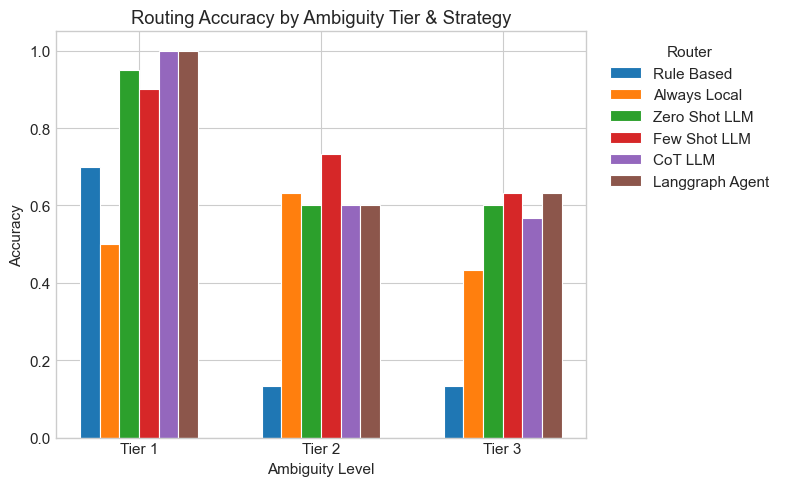

In [3]:
tier_accuracies = []
for tier in [1, 2, 3]:
    mask = df["ambiguity_tier"] == tier
    for router in routers:
        acc = (df[mask][router] == df[mask]["ground_truth"]).mean()
        tier_accuracies.append({
            "router": router.replace("_tool", "").replace("_", " ").title().replace("Llm", "LLM").replace("Cot", "CoT"),
            "tier": f"Tier {tier}",
            "accuracy": acc
        })

acc_df = pd.DataFrame(tier_accuracies)
tier_labels = ["Tier 1", "Tier 2", "Tier 3"]
router_labels = acc_df["router"].unique()
x = np.arange(len(tier_labels))
n = len(router_labels)
width = 0.65 / n
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, router in enumerate(router_labels):
    vals = [acc_df[(acc_df["router"] == router) & (acc_df["tier"] == t)]["accuracy"].values[0] for t in tier_labels]
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, vals, width, color=colors[i % len(colors)], label=router, edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_title("Routing Accuracy by Ambiguity Tier & Strategy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Ambiguity Level")
ax.legend(title="Router", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../data/results/accuracy_vs_tier.png", dpi=300, bbox_inches="tight")
plt.show()

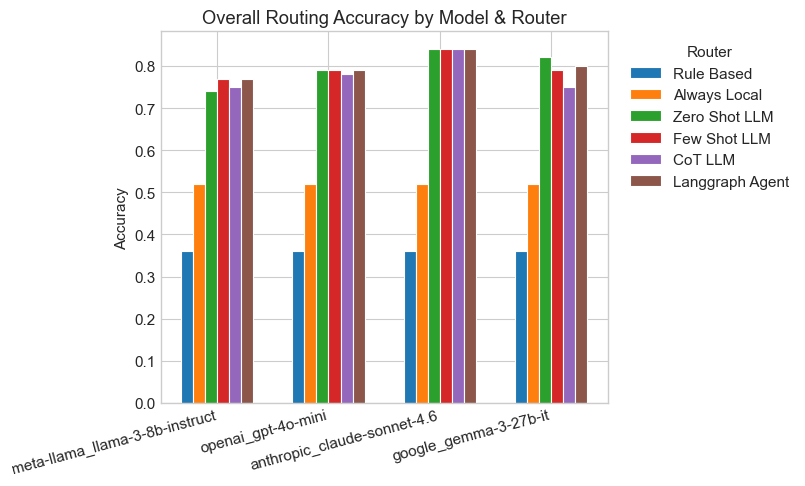

In [4]:
all_csvs = list(RESULTS_DIR.glob("routing_results_*.csv"))
if len(all_csvs) > 1:
    model_acc = []
    for csv_p in all_csvs:
        temp_df = pd.read_csv(csv_p)
        m_name = csv_p.stem.replace("routing_results_", "")
        for router in [c for c in temp_df.columns if c.endswith("_tool")]:
            acc = (temp_df[router] == temp_df["ground_truth"]).mean()
            model_acc.append({"model": m_name, "router": router.replace("_tool", "").replace("_", " ").title().replace("Llm", "LLM").replace("Cot", "CoT"), "accuracy": acc})
    comp_df = pd.DataFrame(model_acc)

    model_labels = comp_df["model"].unique()
    router_labels = comp_df["router"].unique()
    x = np.arange(len(model_labels))
    n = len(router_labels)
    width = 0.65 / n
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, router in enumerate(router_labels):
        vals = [comp_df[(comp_df["model"] == m) & (comp_df["router"] == router)]["accuracy"].values[0] for m in model_labels]
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, vals, width, color=colors[i % len(colors)], label=router, edgecolor="white", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha="right")
    ax.set_title("Overall Routing Accuracy by Model & Router")
    ax.set_ylabel("Accuracy")
    ax.legend(title="Router", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("../data/results/model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
failures = []
for router in routers:
    errs = df[df[router] != df["ground_truth"]]
    for _, row in errs.head(3).iterrows():
        failures.append({
            "router": router.replace("_tool", ""),
            "query_id": row["query_id"],
            "prompt": row["prompt"],
            "ground_truth": row["ground_truth"],
            "predicted": row[router],
            "ambiguity_tier": row["ambiguity_tier"]
        })
 
pd.DataFrame(failures).to_csv("../data/results/qualitative_failures.csv", index=False)
print("Saved to ../data/results/qualitative_failures.csv")
print("\nSample Failures:")
for f in failures[:3]:
    print(f"[{f['router']}] Q{f['query_id']} (Tier {f['ambiguity_tier']})")
    print(f"  GT: {f['ground_truth']} | Pred: {f['predicted']}")
    print(f"  Prompt: \"{f['prompt']}\"\n")

Saved to ../data/results/qualitative_failures.csv

Sample Failures:
[rule_based] Q7 (Tier 1)
  GT: web | Pred: local
  Prompt: "What has Adobe announced in the past month regarding new product launches?"

[rule_based] Q8 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "Which Wall Street analysts have upgraded or downgraded Airbnb stock in the last 30 days?"

[rule_based] Q10 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "What new credit card product did American Express launch this quarter?"



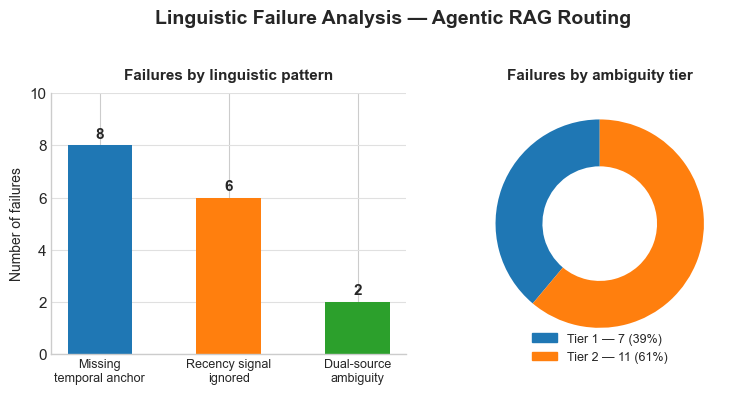

Saved: linguistic_failure_analysis.png


In [6]:
fig = plt.figure(figsize=(8, 4))
fig.suptitle("Linguistic Failure Analysis — Agentic RAG Routing",
             fontsize=14, fontweight='bold', y=0.98)

theme_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# ── Chart 1: Failures by linguistic pattern ──────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
patterns = ["Missing\ntemporal anchor", "Recency signal\nignored", "Dual-source\nambiguity"]
counts   = [8, 6, 2]
colors   = theme_colors[:len(counts)]
bars = ax1.bar(patterns, counts, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 10)
ax1.set_ylabel("Number of failures", fontsize=10)
ax1.set_title("Failures by linguistic pattern", fontsize=11, fontweight='bold', pad=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.grid(True, color='#e0e0e0', zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(axis='x', labelsize=9)

# ── Chart 2: Failures by ambiguity tier (donut) ───────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
tier_vals   = [7, 11]
tier_colors = theme_colors[:len(tier_vals)]
ax2.pie(tier_vals, labels=None, colors=tier_colors,
        startangle=90, wedgeprops=dict(width=0.45))
ax2.set_title("Failures by ambiguity tier", fontsize=11, fontweight='bold', pad=10)
legend_patches = [
    mpatches.Patch(color=tier_colors[0], label="Tier 1 — 7 (39%)"),
    mpatches.Patch(color=tier_colors[1], label="Tier 2 — 11 (61%)")
]
ax2.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../data/results/linguistic_failure_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: linguistic_failure_analysis.png")

/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_36951/1224391224.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["Missing\ntemporal anchor", "Recency signal\nignored", "Dual-source\nambiguity"], fontsize=9)


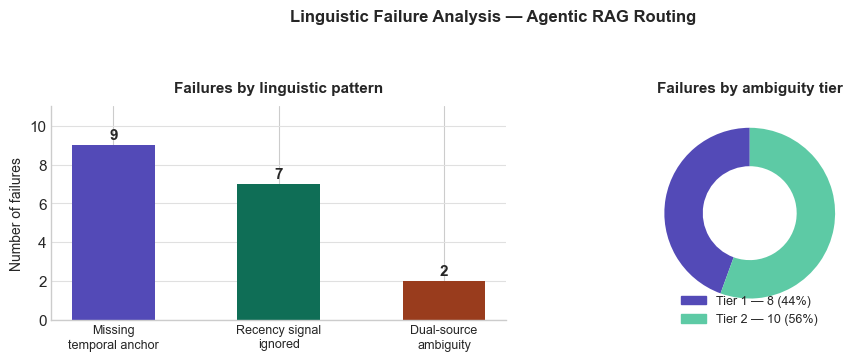

In [7]:
df = pd.read_csv("../data/results/qualitative_failures.csv")

PURPLE = "#534AB7"
TEAL   = "#0F6E56"
CORAL  = "#993C1D"
TEAL2  = "#5DCAA5"
BLUE   = "#378ADD"
GRAY   = "#888780"

LLM_ROUTERS = {"zero_shot_llm", "few_shot_llm", "cot_llm", "langgraph_agent"}

def get_failure_pattern(row):
    prompt = row["prompt"].lower()
    gt     = row["ground_truth"]
    pred   = row["predicted"]

    recency_words = ["right now", "past month", "last 30 days", "this quarter", "current", "today", "latest", "recently"]
    has_recency = any(w in prompt for w in recency_words)

    temporal_words = ["fy", "fiscal", "december", "january", "2024", "2025", "2026", "quarter", "annual", "q1", "q2", "q3", "q4"]
    has_temporal = any(w in prompt for w in temporal_words)

    if has_recency and gt == "web" and pred in ["local", "uncertain"]:
        return "Recency signal ignored"
    elif not has_temporal and not has_recency and gt == "local" and pred == "web":
        return "Missing temporal anchor"
    else:
        return "Dual-source ambiguity"

df["failure_pattern"] = df.apply(get_failure_pattern, axis=1)

pattern_counts = df["failure_pattern"].value_counts().reindex(
    ["Missing temporal anchor", "Recency signal ignored", "Dual-source ambiguity"], fill_value=0
)

tier_counts = df["ambiguity_tier"].value_counts().sort_index()

router_counts = df["router"].value_counts().reindex(
    ["rule_based", "always_local", "zero_shot_llm", "few_shot_llm", "cot_llm", "langgraph_agent"],
    fill_value=0
)
router_colors = [BLUE if r in LLM_ROUTERS else GRAY for r in router_counts.index]

total        = len(df)
unique_prompts = df["query_id"].nunique()
top_pct      = round(pattern_counts.max() / total * 100)

fig = plt.figure(figsize=(10, 6))
fig.suptitle("Linguistic Failure Analysis — Agentic RAG Routing",
             fontsize=12, fontweight='bold', y=0.98)


# ── Chart 1: Failures by linguistic pattern ───────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
bars = ax1.bar(pattern_counts.index, pattern_counts.values, color=[PURPLE, TEAL, CORAL], edgecolor='none', width=0.5)
for bar, val in zip(bars, pattern_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, pattern_counts.max() + 2)
ax1.set_ylabel("Number of failures", fontsize=10)
ax1.set_title("Failures by linguistic pattern", fontsize=11, fontweight='bold', pad=10)
ax1.set_xticklabels(["Missing\ntemporal anchor", "Recency signal\nignored", "Dual-source\nambiguity"], fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.grid(True, color='#e0e0e0', zorder=0)
ax1.set_axisbelow(True)

# ── Chart 2: Failures by ambiguity tier (donut) ───────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
tier_colors_map = {1: PURPLE, 2: TEAL2, 3: CORAL}
t_colors = [tier_colors_map.get(t, GRAY) for t in tier_counts.index]
ax2.pie(tier_counts.values, labels=None, colors=t_colors, startangle=90, wedgeprops=dict(width=0.45))
ax2.set_title("Failures by ambiguity tier", fontsize=11, fontweight='bold', pad=10)
legend_patches = [
    mpatches.Patch(color=tier_colors_map.get(t, GRAY), label=f"Tier {t} — {v} ({round(v/total*100)}%)")
    for t, v in tier_counts.items()
]
ax2.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/results/linguistic_failure_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
